In [1]:
import os
import tensorflow as tf

train_path = "/kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/train"
val_path = "/kaggle/input/datasets/kaustubhb999/tomatoleaf/tomato/val"

image_size = (224, 224)
batch_size = 32

2026-03-24 13:31:40.692240: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774359100.920974      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774359100.984072      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774359101.504952      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774359101.505004      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774359101.505009      55 computation_placer.cc:177] computation placer alr

In [2]:
import pandas as pd

# Load dataset
train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=True,
    seed = 42
)
val_data = tf.keras.utils.image_dataset_from_directory(
    val_path,
    image_size=image_size,
    batch_size=batch_size,
    shuffle=False
)

Found 10000 files belonging to 10 classes.
Found 1000 files belonging to 10 classes.


2026-03-24 13:32:18.385137: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
class_names = train_data.class_names
num_classes = len(class_names)
print(f"Classes [{num_classes}]: {class_names}")

Classes [10]: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [8]:
class_names_short = []

for c in class_names:
    name = c.replace("Tomato___", "").replace("_", " ")
    
    # Custom fixes
    if "Spider mites" in name:
        name = "Spider Mites"
    elif "Yellow Leaf Curl Virus" in name:
        name = "Yellow Leaf Curl Virus"
    elif "mosaic virus" in name.lower():
        name = "Mosaic Virus"
    
    class_names_short.append(name)

In [9]:
# Class distribution
data = []
for i, cls in enumerate(class_names):
    data.append([
        class_names_short[i],
        len(os.listdir(os.path.join(train_path, cls))),
        len(os.listdir(os.path.join(val_path, cls))),
    ])
df = pd.DataFrame(data, columns=["Class_Name", "Train_Images", "Val_Images"])
display(df)

,Class_Name,Train_Images,Val_Images
0,Bacterial spot,1000,100
1,Early blight,1000,100
2,Late blight,1000,100
3,Leaf Mold,1000,100
4,Septoria leaf spot,1000,100
5,Spider Mites,1000,100
6,Target Spot,1000,100
7,Yellow Leaf Curl Virus,1000,100
8,Mosaic Virus,1000,100
9,healthy,1000,100


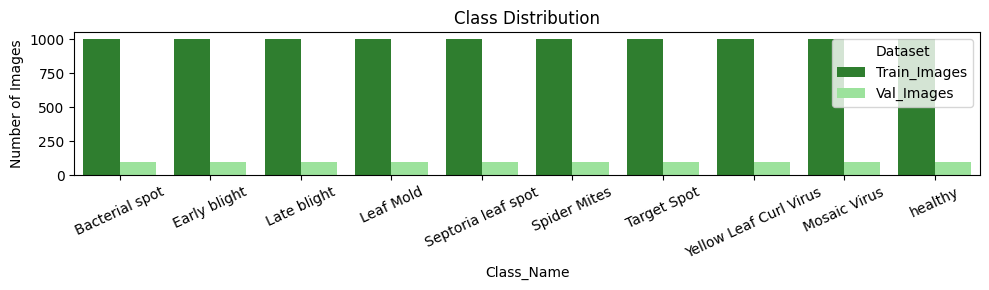

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df_melt = df.melt(id_vars="Class_Name", 
                  value_vars=["Train_Images", "Val_Images"],
                  var_name="Dataset", value_name="Count")

plt.figure(figsize=(10,3))
sns.barplot(data=df_melt, x="Class_Name", y="Count", hue="Dataset",
            palette=["#228B22", "#90EE90"])  # dark green & light green

plt.xticks(rotation=25)
plt.title("Class Distribution")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

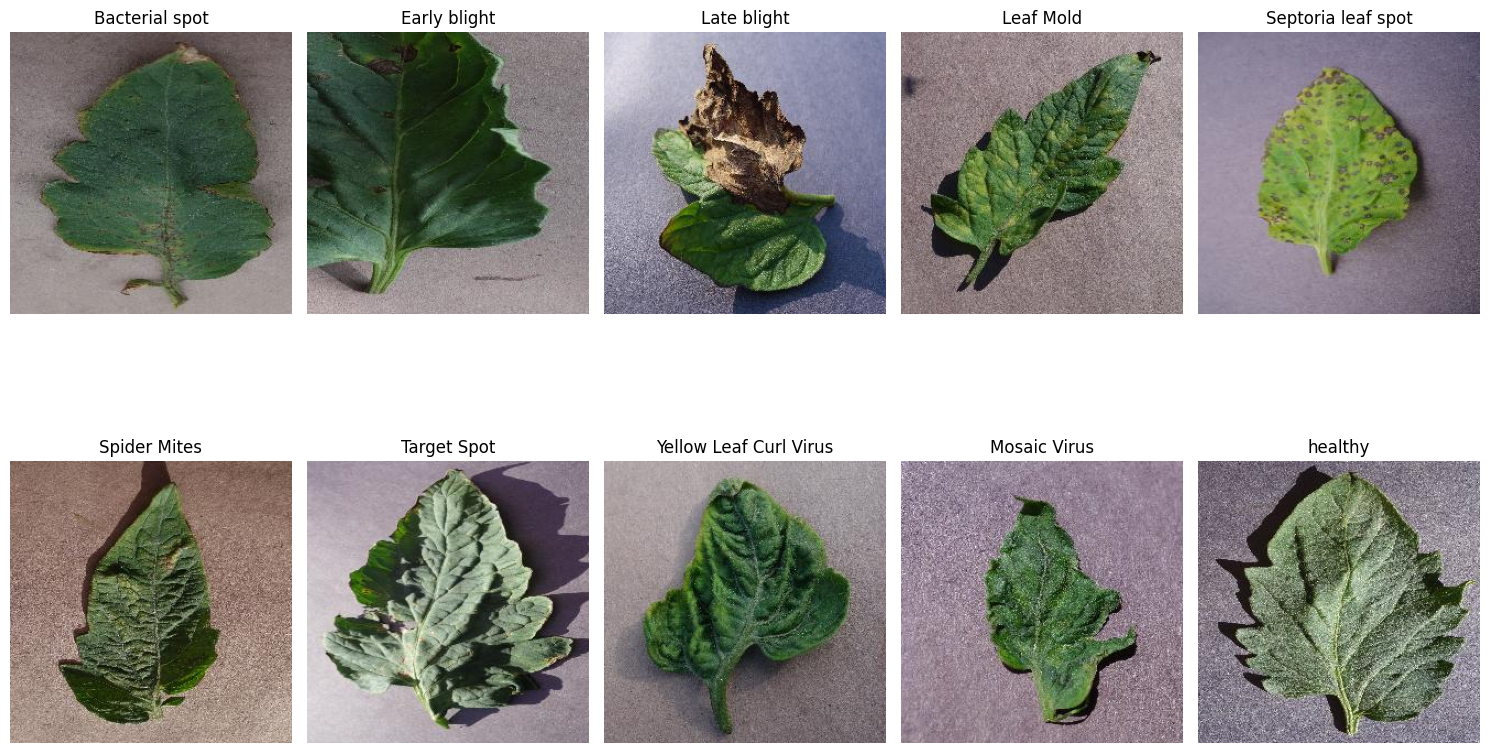

In [13]:
# Sample visualization
import random
import matplotlib.pyplot as plt
from PIL import Image

num_classes = len(class_names)

plt.figure(figsize=(15,10))

for i, cls in enumerate(class_names):

    class_path = os.path.join(train_path, cls)
    images = os.listdir(class_path)

    random_image = random.choice(images)
    img_path = os.path.join(class_path, random_image)

    img = Image.open(img_path)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(class_names_short[i])
    plt.axis("off")

plt.tight_layout()
plt.savefig("sample_viz.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
from tensorflow.keras.applications.efficientnet import preprocess_input

AUTOTUNE = tf.data.AUTOTUNE


def preprocess(image, label):
    return preprocess_input(image), label


train_data = (
    train_data
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(1000)
    .prefetch(AUTOTUNE)
)
val_data = (
    val_data
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

In [15]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.2, 0.2),
], name="data_augmentation")

In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input


def create_model(num_classes: int):

    # Load pretrained EfficientNet
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(*image_size, 3)
    )

    # Freeze pretrained layers
    base_model.trainable = False

    # Build model
    inputs = tf.keras.Input(shape=(*image_size,3))
    x = data_augmentation(inputs)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    
    model = tf.keras.Model(inputs, outputs)

    return model, base_model

In [17]:
model, base_model = create_model(num_classes)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,829 (16.08 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [18]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras", save_best_only=True, verbose=1
)

# Phase 1
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_p1 = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1),
    checkpoint_cb,
]

history_p1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=callbacks_p1,
)

phase1_end = len(history_p1.history["accuracy"])

Epoch 1/10


E0000 00:00:1773653083.275983      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1773653111.859601     108 cuda_dnn.cc:529] Loaded cuDNN version 91002


312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5413 - loss: 1.3526
Epoch 1: val_loss improved from inf to 0.65727, saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 67ms/step - accuracy: 0.5422 - loss: 1.3501 - val_accuracy: 0.7820 - val_loss: 0.6573 - learning_rate: 0.0010
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8096 - loss: 0.5731
Epoch 2: val_loss improved from 0.65727 to 0.45274, saving model to best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 53ms/step - accuracy: 0.8097 - loss: 0.5730 - val_accuracy: 0.8470 - val_loss: 0.4527 - learning_rate: 0.0010
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8309 - loss: 0.4958
Epoch 3: val_loss did not improve from 0.45274
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.8309 - loss: 0.4957 - val_accuracy: 0.8160 - val_loss: 0.5049 - learning_rate: 0.0010
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.8595 - loss: 0.4235
Epoch 4: val_loss imp

In [19]:
# Phase 2
FINE_TUNE_AT = 100
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks_p2 = [
    tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=5, verbose=1),
    checkpoint_cb,
]

history_p2 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    initial_epoch=phase1_end,
    callbacks=callbacks_p2,
)

Epoch 11/100


E0000 00:00:1773653301.757531      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5419 - loss: 1.4982
Epoch 11: val_loss did not improve from 0.31834
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 113ms/step - accuracy: 0.5422 - loss: 1.4970 - val_accuracy: 0.7100 - val_loss: 0.7797 - learning_rate: 1.0000e-05
Epoch 12/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.7727 - loss: 0.6431
Epoch 12: val_loss did not improve from 0.31834
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 103ms/step - accuracy: 0.7728 - loss: 0.6429 - val_accuracy: 0.7490 - val_loss: 0.6669 - learning_rate: 1.0000e-05
Epoch 13/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.8457 - loss: 0.4616
Epoch 13: val_loss did not improve from 0.31834
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 103ms/step - accuracy: 0.8457 - loss: 0.4615 - val_accuracy: 0.7950 - val_loss: 0.5547 - learning_rate: 1.0000e-05
Epoch 14/100
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.8707 - loss: 0.3851
Epoch 14: val_loss did not improve from 0.31834
313/313 ━━━━━━━━━━━━

In [20]:
# Combine history
acc = history_p1.history['accuracy'] + history_p2.history['accuracy']
val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss = history_p1.history['loss'] + history_p2.history['loss']
val_loss = history_p1.history['val_loss'] + history_p2.history['val_loss']

# Best metrics
best_epoch = val_acc.index(max(val_acc))
best_val_acc = max(val_acc)
best_val_loss = val_loss[best_epoch]

phase1_epochs = len(history_p1.history['accuracy'])
phase2_epochs = len(history_p2.history['accuracy'])
total_epochs = len(acc)

print("=" * 60)
print("              MODEL TRAINING SUMMARY")
print("=" * 60)

print("\nTRAINING DURATION")
print(f"   Phase 1 (classification head) : {phase1_epochs} epochs")
print(f"   Phase 2 (fine-tuning)         : {phase2_epochs} epochs")
print(f"   Total training                : {total_epochs} epochs")

print("\nBEST MODEL PERFORMANCE")
print(f"   Best epoch                    : {best_epoch + 1}")
print(f"   Training accuracy             : {acc[best_epoch]*100:.2f}%")
print(f"   Validation accuracy           : {best_val_acc*100:.2f}%")
print(f"   Validation loss               : {best_val_loss:.4f}")

print("\nFINAL TRAINING PERFORMANCE (last epoch)")
print(f"   Training accuracy             : {acc[-1]*100:.2f}%")
print(f"   Validation accuracy           : {val_acc[-1]*100:.2f}%")
print(f"   Validation loss               : {val_loss[-1]:.4f}")


              MODEL TRAINING SUMMARY

TRAINING DURATION
   Phase 1 (classification head) : 10 epochs
   Phase 2 (fine-tuning)         : 90 epochs
   Total training                : 100 epochs

BEST MODEL PERFORMANCE
   Best epoch                    : 99
   Training accuracy             : 99.50%
   Validation accuracy           : 99.20%
   Validation loss               : 0.0271

FINAL TRAINING PERFORMANCE (last epoch)
   Training accuracy             : 99.35%
   Validation accuracy           : 99.10%
   Validation loss               : 0.0272


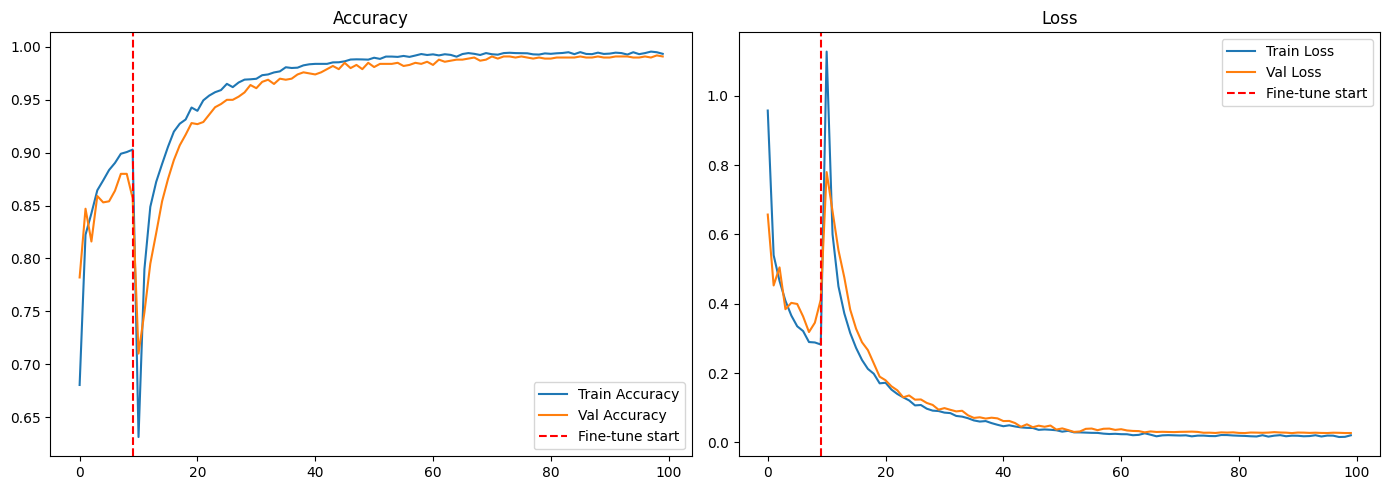

In [23]:
epochs_range = range(len(acc))
phase1_end = len(history_p1.history['accuracy'])

# Plot training history
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Train Accuracy")
plt.plot(epochs_range, val_acc, label="Val Accuracy")
plt.axvline(phase1_end-1, color="red", linestyle="--", label="Fine-tune start")
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Train Loss")
plt.plot(epochs_range, val_loss, label="Val Loss")
plt.axvline(phase1_end-1, color="red", linestyle="--", label="Fine-tune start")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("training_history.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

from tensorflow.keras.models import load_model
model = load_model("/kaggle/input/models/aldeniaalexandra/efficientnetb0/tensorflow2/default/1/best_model.keras")

# Prediction
y_pred_prob = model.predict(val_data)
y_pred = np.argmax(y_pred_prob, axis=1)

# True labels
y_true = np.concatenate([y for x, y in val_data], axis=0)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

32/32 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step


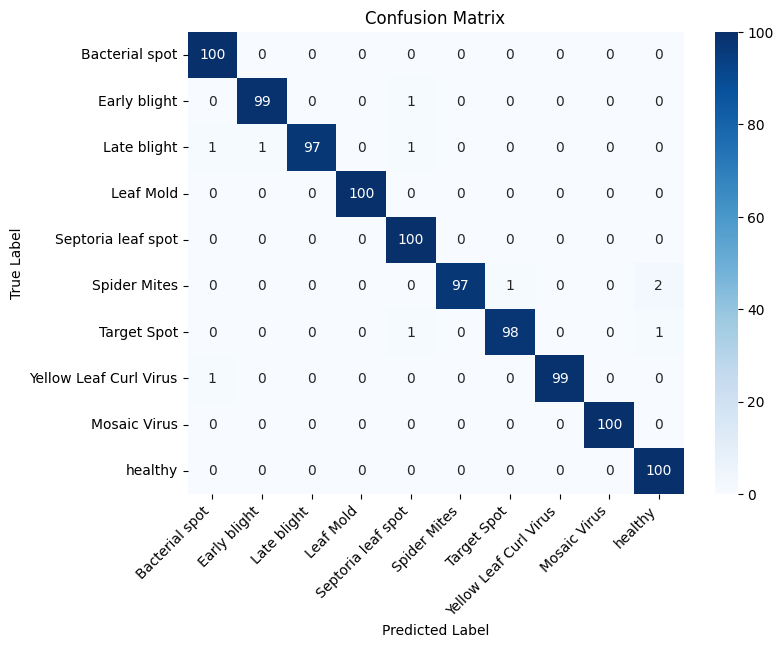

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names_short,
    yticklabels=class_names_short
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names_short))

                        precision    recall  f1-score   support

        Bacterial spot       0.98      1.00      0.99       100
          Early blight       0.99      0.99      0.99       100
           Late blight       1.00      0.97      0.98       100
             Leaf Mold       1.00      1.00      1.00       100
    Septoria leaf spot       0.97      1.00      0.99       100
          Spider Mites       1.00      0.97      0.98       100
           Target Spot       0.99      0.98      0.98       100
Yellow Leaf Curl Virus       1.00      0.99      0.99       100
          Mosaic Virus       1.00      1.00      1.00       100
               healthy       0.97      1.00      0.99       100

              accuracy                           0.99      1000
             macro avg       0.99      0.99      0.99      1000
          weighted avg       0.99      0.99      0.99      1000



In [23]:
from sklearn.metrics import classification_report
import pandas as pd

report_dict = classification_report(
    y_true, y_pred, target_names=class_names_short, output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()

df_f1 = df_report.iloc[:-3][["f1-score"]]
df_f1 = df_f1.sort_values(by="f1-score", ascending=True)

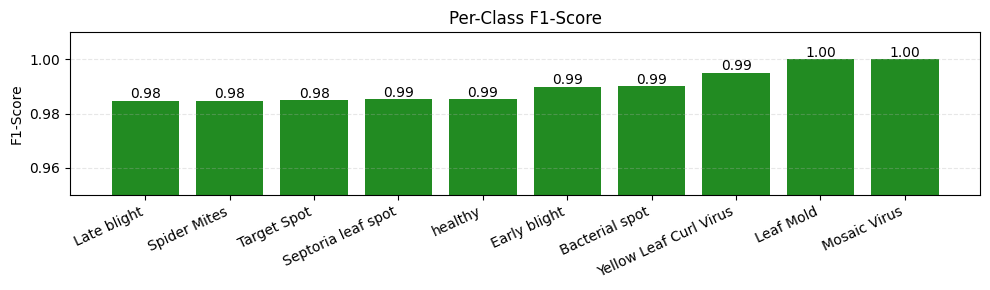

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))

bars = plt.bar(
    df_f1.index,
    df_f1["f1-score"],
    color="forestgreen"
)

for i, v in enumerate(df_f1["f1-score"]):
    plt.text(i, v + 0.001, f"{v:.2f}", ha='center')

plt.ylabel("F1-Score")
plt.title("Per-Class F1-Score")

plt.xticks(rotation=25, ha='right')

plt.ylim(0.95, 1.01)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig("F1Score.png", dpi=300, bbox_inches="tight")
plt.show()